# Cross-Dataset Train/Test Swap

This notebook trains the same basic CNN across datasets instead of mixing them. Set `TRAIN_ON_CUI` at the top:

- `True`: train/validate on Cui, test on Orosco
- `False`: train/validate on Orosco, test on Cui


In [13]:
from pathlib import Path

CUI_PATH = Path("../../data/driver-drowsiness/cui/dataset.mat")
OROSCO_PATH = Path("../../data/driver-drowsiness/orosco/dataset/orosco_windowed_balanced.npz")

TRAIN_ON_CUI = True  # True: Cui -> Orosco, False: Orosco -> Cui


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.io import loadmat
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

device


device(type='mps')

## Dataset Loading


In [15]:
class EEGDatasetBundle:
    def __init__(self, name, X, y, subjects, channels):
        self.name = name
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.subjects = subjects.astype(np.int64)
        self.channels = list(channels)

    def summary(self):
        labels = dict(zip(*np.unique(self.y, return_counts=True)))
        return {
            "dataset": self.name,
            "shape": self.X.shape,
            "labels": labels,
            "subjects": np.unique(self.subjects).tolist(),
            "channels": self.channels,
        }


class DriverDrowsinessLoader:
    label_names = {0: "alert", 1: "drowsy"}
    shared_channels = ["O1", "O2", "C3", "C4"]

    cui_channel_names = [
        "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8",
        "FT7", "FC3", "FCz", "FC4", "FT8",
        "T3", "C3", "Cz", "C4", "T4",
        "TP7", "CP3", "CPz", "CP4", "TP8",
        "T5", "P3", "Pz", "P4", "T6",
        "O1", "Oz", "O2",
    ]

    @classmethod
    def load_cui(cls, path):
        mat = loadmat(path)
        X_full = mat["EEGsample"].astype(np.float32)
        y = mat["substate"].reshape(-1).astype(np.int64)
        subjects = mat["subindex"].reshape(-1).astype(np.int64)
        shared_indices = [cls.cui_channel_names.index(channel) for channel in cls.shared_channels]
        X = X_full[:, shared_indices, :]
        return EEGDatasetBundle("cui", X, y, subjects, cls.shared_channels)

    @classmethod
    def load_orosco(cls, path):
        data = np.load(path, allow_pickle=True)
        X = data["X"].astype(np.float32)
        y = data["Y"].astype(np.int64)
        subjects = data["subjects"].astype(np.int64)
        channels = [str(channel).replace("-Ref", "") for channel in data["channels"].tolist()]
        return EEGDatasetBundle("orosco", X, y, subjects, channels)


cui = DriverDrowsinessLoader.load_cui(CUI_PATH)
orosco = DriverDrowsinessLoader.load_orosco(OROSCO_PATH)

display(pd.DataFrame([cui.summary(), orosco.summary()]))


,dataset,shape,labels,subjects,channels
0,cui,"(2022, 4, 384)","{0: 1011, 1: 1011}","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[O1, O2, C3, C4]"
1,orosco,"(6364, 4, 384)","{0: 3182, 1: 3182}","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[O1, O2, C3, C4]"


## Choose Direction


In [16]:
if TRAIN_ON_CUI:
    train_bundle = cui
    test_bundle = orosco
else:
    train_bundle = orosco
    test_bundle = cui

print(f"Training on: {train_bundle.name}")
print(f"Testing on:  {test_bundle.name}")


Training on: cui
Testing on:  orosco


## Train/Validation Split


In [17]:
def subject_train_val_split(bundle, val_fraction=0.2):
    unique_subjects = np.unique(bundle.subjects)
    rng = np.random.default_rng(42)
    shuffled = rng.permutation(unique_subjects)
    n_val_subjects = max(1, int(round(len(shuffled) * val_fraction)))
    val_subjects = np.sort(shuffled[:n_val_subjects])
    train_subjects = np.sort(shuffled[n_val_subjects:])

    train_mask = np.isin(bundle.subjects, train_subjects)
    val_mask = np.isin(bundle.subjects, val_subjects)
    return train_mask, val_mask, train_subjects, val_subjects


train_mask, val_mask, train_subjects, val_subjects = subject_train_val_split(train_bundle)

X_train, y_train = train_bundle.X[train_mask], train_bundle.y[train_mask]
X_val, y_val = train_bundle.X[val_mask], train_bundle.y[val_mask]
X_test, y_test = test_bundle.X, test_bundle.y

channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6

X_train = (X_train - channel_mean) / channel_std
X_val = (X_val - channel_mean) / channel_std
X_test = (X_test - channel_mean) / channel_std

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "dataset": [train_bundle.name, train_bundle.name, test_bundle.name],
    "subjects": [train_subjects.tolist(), val_subjects.tolist(), np.unique(test_bundle.subjects).tolist()],
    "samples": [len(y_train), len(y_val), len(y_test)],
    "alert": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    "drowsy": [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
})

display(split_summary)


,split,dataset,subjects,samples,alert,drowsy
0,train,cui,"[1, 2, 3, 4, 5, 6, 9, 10, 11]",1656,828,828
1,val,cui,"[7, 8]",366,183,183
2,test,orosco,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6364,3182,3182


## DataLoaders


In [18]:
batch_size = 32

def make_loader(X_array, y_array, shuffle=False):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.long)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

xb, yb = next(iter(train_loader))
print("batch X:", xb.shape)
print("batch y:", yb.shape)


batch X: torch.Size([32, 4, 384])
batch y: torch.Size([32])


## Model


In [19]:
class BasicEEGCNN(nn.Module):
    def __init__(self, n_channels=4, n_times=384, n_classes=2):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Flatten(),
        )

        with torch.no_grad():
            flattened_size = self.conv(torch.zeros(1, n_channels, n_times)).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ELU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.fc(self.conv(x))


model = BasicEEGCNN(n_channels=X_train.shape[1], n_times=X_train.shape[2]).to(device)
model


BasicEEGCNN(
  (conv): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ELU(alpha=1.0)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ELU(alpha=1.0)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ELU(alpha=1.0)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc): Sequential(
    (0): Linear(in_features=3072, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

## Training Utilities


In [20]:
def binary_f1_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    f1_scores = []

    for label in [0, 1]:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1_scores.append(2 * precision * recall / (precision + recall + 1e-12))

    return float(np.mean(f1_scores))


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * batch_x.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": float((all_preds == all_targets).mean()),
        "f1_macro": binary_f1_score(all_targets, all_preds),
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


## Train


In [21]:
learning_rate = 1e-3
epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

history = []
best_val_f1 = -1.0
best_state = None

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    train_metrics = evaluate(model, train_loader, criterion)
    val_metrics = evaluate(model, val_loader, criterion)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1_macro"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1_macro"],
    })

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_metrics['accuracy']:.3f} f1 {train_metrics['f1_macro']:.3f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.3f} f1 {val_metrics['f1_macro']:.3f}"
    )

history_df = pd.DataFrame(history)
display(history_df.tail())


epoch 01 | train loss 0.5978 acc 0.690 f1 0.670 | val loss 0.6349 acc 0.708 f1 0.708
epoch 02 | train loss 0.5064 acc 0.829 f1 0.828 | val loss 0.7677 acc 0.634 f1 0.620
epoch 03 | train loss 0.4356 acc 0.853 f1 0.853 | val loss 0.8564 acc 0.609 f1 0.584
epoch 04 | train loss 0.4023 acc 0.882 f1 0.882 | val loss 0.9012 acc 0.604 f1 0.581
epoch 05 | train loss 0.3548 acc 0.908 f1 0.908 | val loss 0.8918 acc 0.615 f1 0.602
epoch 06 | train loss 0.2718 acc 0.938 f1 0.938 | val loss 1.0008 acc 0.631 f1 0.618
epoch 07 | train loss 0.2205 acc 0.966 f1 0.966 | val loss 1.3112 acc 0.628 f1 0.616
epoch 08 | train loss 0.1721 acc 0.975 f1 0.975 | val loss 1.6454 acc 0.585 f1 0.559
epoch 09 | train loss 0.1257 acc 0.989 f1 0.989 | val loss 1.8213 acc 0.601 f1 0.578
epoch 10 | train loss 0.0672 acc 0.996 f1 0.996 | val loss 2.3303 acc 0.596 f1 0.567
epoch 11 | train loss 0.0557 acc 0.989 f1 0.989 | val loss 3.0141 acc 0.574 f1 0.531
epoch 12 | train loss 0.0933 acc 0.983 f1 0.983 | val loss 2.5785

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
15,16,0.004597,1.0,1.0,2.878779,0.636612,0.622402
16,17,0.003525,1.0,1.0,3.053015,0.639344,0.623093
17,18,0.001452,1.0,1.0,3.084440,0.639344,0.623093
18,19,0.001348,1.0,1.0,3.188370,0.639344,0.621249
19,20,0.001105,1.0,1.0,3.063337,0.633880,0.619141


## Learning Curves


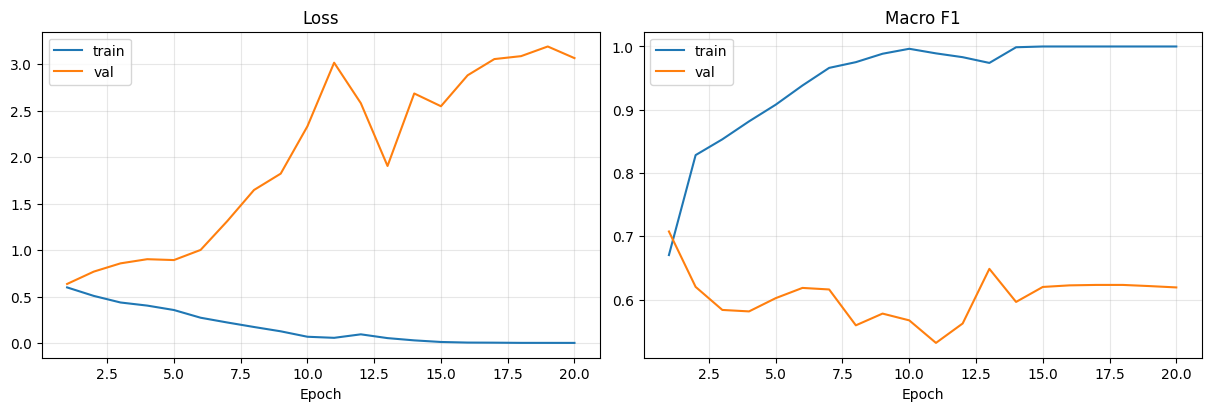

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_f1"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_f1"], label="val")
axes[1].set_title("Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()


## Cross-Dataset Test


In [23]:
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

test_metrics = evaluate(model, test_loader, criterion)
test_metrics


{'loss': 0.6512996191726699,
 'accuracy': 0.6759899434318039,
 'f1_macro': 0.6495507863904216}